# high_confidence_subset

Create conservative and relaxed candidate subsets before building the first baseline.

Idea:
- prefer higher-rated recordings
- downweight recordings with many secondary labels
- inspect class loss after filtering
- compare a strict rule against a relaxed rule
- rescue classes where rating metadata is unusable

In [25]:
from pathlib import Path
import ast

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

ROOT = Path.cwd().resolve()
if ROOT.name == "exp000_eda":
    ROOT = ROOT.parents[1]
elif not (ROOT / "train.csv").exists():
    raise FileNotFoundError("Run this notebook from the repository root or experiments/exp000_eda.")

ROOT

PosixPath('/Users/shionsuio/Downloads/BirdCLEF 2026')

In [26]:
train = pd.read_csv(ROOT / "train.csv")
taxonomy = pd.read_csv(ROOT / "taxonomy.csv")

train["secondary_count"] = (
    train["secondary_labels"]
    .fillna("[]")
    .map(lambda x: len(ast.literal_eval(x)) if isinstance(x, str) else 0)
)

train["rating"] = pd.to_numeric(train["rating"], errors="coerce")
train[["primary_label", "rating", "secondary_count", "type"]].head()

,primary_label,rating,secondary_count,type
0,1161364,0.0,0,[]
1,1161364,0.0,0,[]
2,1161364,0.0,0,[]
3,1161364,0.0,0,[]
4,1161364,0.0,0,[]


## Filter definitions

In [27]:
STRICT_MIN_RATING = 4.0
STRICT_MAX_SECONDARY = 1

RELAXED_MIN_RATING = 3.5
RELAXED_MAX_SECONDARY = 2


def build_subset(df: pd.DataFrame, min_rating: float, max_secondary: int) -> pd.DataFrame:
    subset = df.loc[df["rating"].fillna(0) >= min_rating]
    subset = subset.loc[subset["secondary_count"] <= max_secondary].copy()
    return subset


strict = build_subset(train, STRICT_MIN_RATING, STRICT_MAX_SECONDARY)
relaxed = build_subset(train, RELAXED_MIN_RATING, RELAXED_MAX_SECONDARY)

## Rating-less class rescue

If a class has no usable rating metadata at all, do not let the rating threshold delete it completely.

In [28]:
rating_profile = (
    train.groupby("primary_label")
    .agg(
        n=("filename", "size"),
        rating_max=("rating", "max"),
        rating_mean=("rating", "mean"),
        secondary_mean=("secondary_count", "mean"),
    )
)

ratingless_labels = rating_profile.index[rating_profile["rating_max"].fillna(0) <= 0].tolist()
len(ratingless_labels), ratingless_labels[:20]

(21,
 ['1161364',
  '116570',
  '1176823',
  '209233',
  '22967',
  '22983',
  '23150',
  '23154',
  '23724',
  '24321',
  '244024',
  '25214',
  '476521',
  '516975',
  '555123',
  '66971',
  '70711',
  '760266',
  'ocecra1',
  'sptnig1'])

In [29]:
rescued_unrated = train.loc[
    train["primary_label"].isin(ratingless_labels)
].copy()

rescued = pd.concat([strict, rescued_unrated], ignore_index=True).drop_duplicates(subset=["filename"])
rescued

,primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,class_name,inat_taxon_id,author,license,rating,url,filename,collection,secondary_count
0,1595929,[],['uncertain'],-28.5332,-57.1670,Lysapsus limellum,Uruguay Harlequin Frog,Amphibia,1595929,Franco Vushurovich,by-nc-sa,5.0,https://xeno-canto.org/999239/download,1595929/XC999239.ogg,XC,0
1,22956,[],['advertisement call'],-32.2269,-58.1515,Leptodactylus mystacinus,Mustached Frog,Amphibia,22956,Guillermo Treboux,by-nc-sa,4.0,https://xeno-canto.org/900618/download,22956/XC900618.ogg,XC,0
2,22961,[],['uncertain'],-20.3244,-50.2553,Leptodactylus podicipinus,Pointedbelly Frog,Amphibia,22961,Fabrício Grigolin,by-nc-sa,5.0,https://xeno-canto.org/1062603/download,22961/XC1062603.ogg,XC,0
3,22973,[],['uncertain'],-20.3244,-50.2553,Leptodactylus fuscus,Whistling Grass Frog,Amphibia,22973,Fabrício Grigolin,by-nc-sa,4.0,https://xeno-canto.org/1062605/download,22973/XC1062605.ogg,XC,0
4,22973,[],['territorial call'],-14.1825,-67.9316,Leptodactylus fuscus,Whistling Grass Frog,Amphibia,22973,GABRIEL LEITE,by-nc-sa,4.0,https://xeno-canto.org/1065541/download,22973/XC1065541.ogg,XC,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16484,yehcar1,[],[],10.4985,-66.8941,Daptrius chimachima,Yellow-headed Caracara,Aves,1432779,Alejandro Luy,cc-by-nc,0.0,https://static.inaturalist.org/sounds/630962.m...,yehcar1/iNat630962.ogg,iNat,0
16485,yehcar1,[],[],10.4989,-66.8941,Daptrius chimachima,Yellow-headed Caracara,Aves,1432779,Alejandro Luy,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1271296....,yehcar1/iNat1271296.ogg,iNat,0
16486,yehcar1,[],[],11.0324,-74.8672,Daptrius chimachima,Yellow-headed Caracara,Aves,1432779,Miguel Ángel Serrano,cc-by-nc,0.0,https://static.inaturalist.org/sounds/497254.m...,yehcar1/iNat497254.ogg,iNat,0
16487,yehcar1,[],[],11.1647,-60.8249,Daptrius chimachima,Yellow-headed Caracara,Aves,1432779,Merryl See Tai,cc-by-nc,0.0,https://static.inaturalist.org/sounds/483174.m...,yehcar1/iNat483174.ogg,iNat,0


In [30]:
comparison = pd.DataFrame([
    {
        "subset": "strict",
        "rows": len(strict),
        "retention": len(strict) / len(train),
        "classes": strict["primary_label"].nunique(),
    },
    {
        "subset": "relaxed",
        "rows": len(relaxed),
        "retention": len(relaxed) / len(train),
        "classes": relaxed["primary_label"].nunique(),
    },
    {
        "subset": "strict_plus_ratingless",
        "rows": len(rescued),
        "retention": len(rescued) / len(train),
        "classes": rescued["primary_label"].nunique(),
    },
])
comparison

,subset,rows,retention,classes
0,strict,16131,0.453768,181
1,relaxed,17929,0.504346,182
2,strict_plus_ratingless,16489,0.463839,202


In [31]:
orig_counts = train["primary_label"].value_counts().rename("original_count")
strict_counts = strict["primary_label"].value_counts().rename("strict_count")
relaxed_counts = relaxed["primary_label"].value_counts().rename("relaxed_count")
rescued_counts = rescued["primary_label"].value_counts().rename("rescued_count")

coverage = pd.concat([orig_counts, strict_counts, relaxed_counts, rescued_counts], axis=1).fillna(0)
coverage[["strict_count", "relaxed_count", "rescued_count"]] = coverage[["strict_count", "relaxed_count", "rescued_count"]].astype(int)
coverage["strict_retention"] = coverage["strict_count"] / coverage["original_count"]
coverage["relaxed_retention"] = coverage["relaxed_count"] / coverage["original_count"]
coverage["rescued_retention"] = coverage["rescued_count"] / coverage["original_count"]
coverage["rescued_by_relaxed"] = (coverage["strict_count"] == 0) & (coverage["relaxed_count"] > 0)
coverage["rescued_by_ratingless"] = (coverage["strict_count"] == 0) & (coverage["rescued_count"] > 0)
coverage.head()

,original_count,strict_count,relaxed_count,rescued_count,strict_retention,relaxed_retention,rescued_retention,rescued_by_relaxed,rescued_by_ratingless
primary_label,,,,,,,,,
rubthr1,499,169,184,169,0.338677,0.368737,0.338677,False,False
banana,498,239,260,239,0.479920,0.522088,0.479920,False,False
fepowl,497,139,155,139,0.279678,0.311871,0.279678,False,False
soulap1,497,204,217,204,0.410463,0.436620,0.410463,False,False
houspa,496,78,78,78,0.157258,0.157258,0.157258,False,False


In [32]:
coverage.sort_values(["rescued_count", "original_count"], ascending=[False, False]).head(20)

,original_count,strict_count,relaxed_count,rescued_count,strict_retention,relaxed_retention,rescued_retention,rescued_by_relaxed,rescued_by_ratingless
primary_label,,,,,,,,,
yeofly1,493,310,339,310,0.628803,0.687627,0.628803,False,False
squcuc1,432,266,284,266,0.615741,0.657407,0.615741,False,False
greant1,475,254,286,254,0.534737,0.602105,0.534737,False,False
bncfly,492,245,266,245,0.497967,0.540650,0.497967,False,False
sobtyr1,490,245,277,245,0.500000,0.565306,0.500000,False,False
oliwoo1,424,244,264,244,0.575472,0.622642,0.575472,False,False
banana,498,239,260,239,0.479920,0.522088,0.479920,False,False
eulfly1,355,235,257,235,0.661972,0.723944,0.661972,False,False
bobfly1,492,222,242,222,0.451220,0.491870,0.451220,False,False


In [33]:
strict_lost = coverage.loc[coverage["strict_count"] == 0].sort_values("original_count", ascending=False)
strict_lost.head(20)

,original_count,strict_count,relaxed_count,rescued_count,strict_retention,relaxed_retention,rescued_retention,rescued_by_relaxed,rescued_by_ratingless
primary_label,,,,,,,,,
244024,181,0,0,181,0.0,0.000000,1.0,False,True
yehcar1,82,0,0,82,0.0,0.000000,1.0,False,True
326272,28,0,2,0,0.0,0.071429,0.0,True,False
ocecra1,15,0,0,15,0.0,0.000000,1.0,False,True
1176823,12,0,0,12,0.0,0.000000,1.0,False,True
1161364,11,0,0,11,0.0,0.000000,1.0,False,True
22983,10,0,0,10,0.0,0.000000,1.0,False,True
555145,9,0,0,0,0.0,0.000000,0.0,False,False
22967,8,0,0,8,0.0,0.000000,1.0,False,True


In [34]:
rescued_relaxed = coverage.loc[coverage["rescued_by_relaxed"]].sort_values("relaxed_count", ascending=False)
rescued_relaxed.head(20)

,original_count,strict_count,relaxed_count,rescued_count,strict_retention,relaxed_retention,rescued_retention,rescued_by_relaxed,rescued_by_ratingless
primary_label,,,,,,,,,
326272,28,0,2,0,0.0,0.071429,0.0,True,False


In [35]:
rescued_ratingless = coverage.loc[coverage["rescued_by_ratingless"]].sort_values("rescued_count", ascending=False)
rescued_ratingless.head(20)

,original_count,strict_count,relaxed_count,rescued_count,strict_retention,relaxed_retention,rescued_retention,rescued_by_relaxed,rescued_by_ratingless
primary_label,,,,,,,,,
244024,181,0,0,181,0.0,0.0,1.0,False,True
yehcar1,82,0,0,82,0.0,0.0,1.0,False,True
ocecra1,15,0,0,15,0.0,0.0,1.0,False,True
1176823,12,0,0,12,0.0,0.0,1.0,False,True
1161364,11,0,0,11,0.0,0.0,1.0,False,True
22983,10,0,0,10,0.0,0.0,1.0,False,True
22967,8,0,0,8,0.0,0.0,1.0,False,True
760266,7,0,0,7,0.0,0.0,1.0,False,True
23154,5,0,0,5,0.0,0.0,1.0,False,True


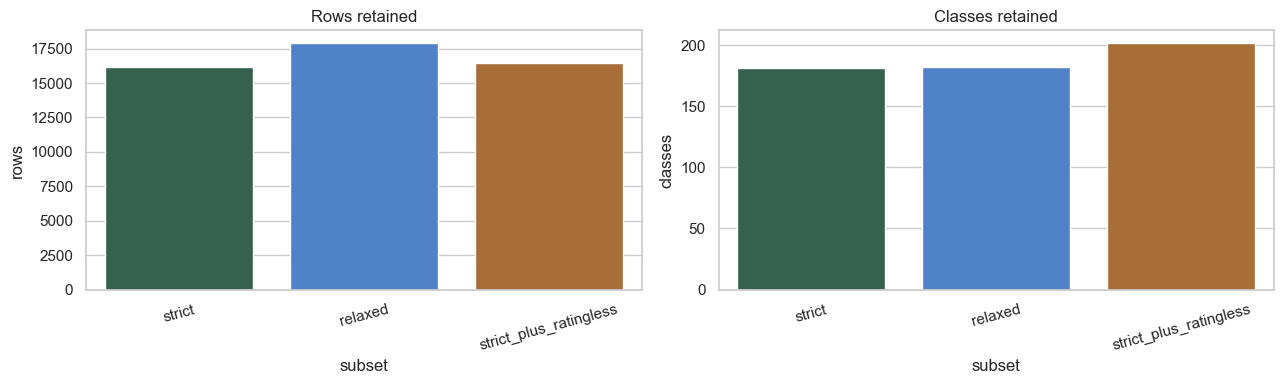

In [36]:
plot_df = comparison.copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.barplot(data=plot_df, x="subset", y="rows", ax=axes[0], hue="subset", palette=["#2d6a4f", "#3b7ddd", "#bc6c25"], legend=False)
axes[0].set_title("Rows retained")
axes[0].tick_params(axis="x", rotation=15)

sns.barplot(data=plot_df, x="subset", y="classes", ax=axes[1], hue="subset", palette=["#2d6a4f", "#3b7ddd", "#bc6c25"], legend=False)
axes[1].set_title("Classes retained")
axes[1].tick_params(axis="x", rotation=15)
plt.tight_layout()

## Investigate lost classes

Focus on the largest classes that disappear under the strict rule. These are the most likely candidates for class-specific exceptions.

In [37]:
lost_labels = strict_lost.head(10).index.tolist()
lost_labels

['244024',
 'yehcar1',
 '326272',
 'ocecra1',
 '1176823',
 '1161364',
 '22983',
 '555145',
 '22967',
 '760266']

In [38]:
lost_profile = (
    train.loc[train["primary_label"].isin(lost_labels)]
    .groupby("primary_label")
    .agg(
        n=("filename", "size"),
        rating_mean=("rating", "mean"),
        rating_median=("rating", "median"),
        rating_max=("rating", "max"),
        secondary_mean=("secondary_count", "mean"),
        secondary_median=("secondary_count", "median"),
        unique_types=("type", lambda x: x.fillna("<missing>").nunique()),
    )
    .sort_values("n", ascending=False)
)
lost_profile

,n,rating_mean,rating_median,rating_max,secondary_mean,secondary_median,unique_types
primary_label,,,,,,,
244024,181,0.000000,0.0,0.0,0.000000,0.0,1
yehcar1,82,0.000000,0.0,0.0,0.000000,0.0,1
326272,28,0.446429,0.0,4.5,0.250000,0.0,2
ocecra1,15,0.000000,0.0,0.0,0.000000,0.0,1
1176823,12,0.000000,0.0,0.0,0.000000,0.0,1
1161364,11,0.000000,0.0,0.0,0.000000,0.0,1
22983,10,0.000000,0.0,0.0,0.000000,0.0,1
555145,9,0.611111,0.0,3.0,0.111111,0.0,2
22967,8,0.000000,0.0,0.0,0.000000,0.0,1


In [39]:
focus_label = lost_labels[0] if lost_labels else None
focus_label

'244024'

In [40]:
if focus_label is not None:
    focus_rows = train.loc[train["primary_label"] == focus_label, ["filename", "rating", "secondary_count", "type", "secondary_labels"]].copy()
    display(focus_rows.head(20))
    display(focus_rows[["rating", "secondary_count"]].describe())

,filename,rating,secondary_count,type,secondary_labels
276,244024/iNat269695.ogg,0.0,0,[],[]
277,244024/iNat55191.ogg,0.0,0,[],[]
278,244024/iNat1273075.ogg,0.0,0,[],[]
279,244024/iNat1272883.ogg,0.0,0,[],[]
280,244024/iNat571275.ogg,0.0,0,[],[]
281,244024/iNat1265454.ogg,0.0,0,[],[]
282,244024/iNat1265455.ogg,0.0,0,[],[]
283,244024/iNat1265530.ogg,0.0,0,[],[]
284,244024/iNat150545.ogg,0.0,0,[],[]
285,244024/iNat858495.ogg,0.0,0,[],[]


,rating,secondary_count
count,181.0,181.0
mean,0.0,0.0
std,0.0,0.0
min,0.0,0.0
25%,0.0,0.0
50%,0.0,0.0
75%,0.0,0.0
max,0.0,0.0


## Working decision for first submission

Use this project stage to get a submission out quickly rather than optimize filtering too deeply.

Recommended short-term plan:
- Train the first baseline on `strict_plus_ratingless`.
- Keep the full training set available as a later comparison.
- Do not over-engineer denoising yet.
- After the first submission, compare score before deciding whether to widen the training set further or add class-specific exceptions.

## Export candidate subsets

Keep these local unless you decide the format is stable enough to track.

In [41]:
strict_path = ROOT / "experiments" / "exp000_eda" / "high_confidence_candidates.csv"
relaxed_path = ROOT / "experiments" / "exp000_eda" / "high_confidence_candidates_relaxed.csv"
rescued_path = ROOT / "experiments" / "exp000_eda" / "high_confidence_candidates_rescued.csv"

strict.to_csv(strict_path, index=False)
relaxed.to_csv(relaxed_path, index=False)
rescued.to_csv(rescued_path, index=False)

strict_path, relaxed_path, rescued_path

(PosixPath('/Users/shionsuio/Downloads/BirdCLEF 2026/experiments/exp000_eda/high_confidence_candidates.csv'),
 PosixPath('/Users/shionsuio/Downloads/BirdCLEF 2026/experiments/exp000_eda/high_confidence_candidates_relaxed.csv'),
 PosixPath('/Users/shionsuio/Downloads/BirdCLEF 2026/experiments/exp000_eda/high_confidence_candidates_rescued.csv'))

## Next questions

- How many classes are recovered by the rating-less rescue?
- Does the first submission work better with `strict_plus_ratingless` than strict alone?
- Should some rescued classes still be downweighted later?
- After the first score, is it better to widen data or improve features/modeling?